In [7]:
import numpy as np
import matplotlib.pyplot as plt

from time import time
from utils.colors import C5
from numpy.typing import NDArray
from utils.utils import progress_bar
from algorithms.matrix_free_rsvd import MatrixFreeRSVD
from fenics import (
    FunctionSpace, DirichletBC, Constant, TrialFunction, TestFunction,
    dot, grad, dx, assemble, UnitSquareMesh
)

# LaTeX formatted figures
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 15,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

M = ['o', '*', '^', 's']
MS = [6, 8, 6, 6]

In [2]:
class AssembleForwardOperator:
    """
    Assemble the forward operator K and record the computational time.
    """
    def __init__(self, V_h: FunctionSpace):
        self.V_h = V_h
        self.bdofs = self._get_boundary_dofs()
        self.N = V_h.dim()
        self.N_b = len(self.bdofs)
        self.dt = None
    
    def assemble_K(self) -> NDArray:
        """Get the exact discrete forward operator K"""
        t0 = time()
        S = self.assemble_S()
        T = self.assemble_T()
        self.dt = time() - t0 
        return T @ S
    
    def assemble_S(self, sigma: float=1.0, k: float=1.0) -> NDArray:
        """Get the exact discrete PDE operator S."""
        u = TrialFunction(self.V_h)
        v = TestFunction(self.V_h)

        sigma = Constant(sigma)
        k = Constant(k)
        a = sigma * dot(grad(u), grad(v)) * dx + k * u * v * dx  # LHS
        m = u * v * dx  # RHS

        # Assemble A, M and S
        A = assemble(a).array()
        M = assemble(m).array()
        S = np.linalg.solve(A, M)  # S = A^{-1} @ M
        return S
    
    def assemble_T(self) -> NDArray:
        """Get the exact discrete trace operator T."""
        T = np.zeros((self.N_b, self.N))
        for i, j in enumerate(self.bdofs):
            T[i, j] = 1.0
        return T
    
    def _get_boundary_dofs(self) -> NDArray:
        def boundary(x, on_boundary):
            return on_boundary

        bc = DirichletBC(self.V_h, Constant(0.0), boundary)
        bc_dict = bc.get_boundary_values()
        return np.array(sorted(bc_dict.keys()), dtype=int)
    

def setup_function_space(n):
    mesh = UnitSquareMesh(n, n)
    V_h = FunctionSpace(mesh, 'CG', 1)
    return V_h


In [39]:
from utils.mesh_utils import get_square_f, Function
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W, tikhonov_solver
from fenics import plot


In [118]:
def compute_f_for_different_n(k):
    f_list = []
    for n in [32, 128, 512]:
        mesh = UnitSquareMesh(n, n)
        V_h = FunctionSpace(mesh, 'CG', 1)
        rsvd = MatrixFreeRSVD(V_h)
        f = get_square_f(V_h, x0=0.2, y0=0.2, w=0.15, h=0.15)
        x = f.vector().get_local()
        y = rsvd.apply_K(x)

        N_b = rsvd.N_b
        print(f"N_b={N_b}, k={k}, k/N_b={k / N_b:.2f}")

        Uk, Sk, VkT = rsvd.mf_rsvd(k=k)
        w = get_approximate_W(VkT.T, rsvd.M_dx)
        x = tikhonov_solver(rsvd, w, y, lambda_=1e-3)

        f_hat = Function(V_h)
        f_hat.vector()[:] = x
        f_list.append(f_hat)
    
    return f_list
    

f_list_10 = compute_f_for_different_n(k=10)
f_list_25 = compute_f_for_different_n(k=25)
f_list_50 = compute_f_for_different_n(k=50)

N_b=128, k=10, k/N_b=0.08
N_b=512, k=10, k/N_b=0.02
N_b=2048, k=10, k/N_b=0.00
N_b=128, k=25, k/N_b=0.20
N_b=512, k=25, k/N_b=0.05
N_b=2048, k=25, k/N_b=0.01
N_b=128, k=50, k/N_b=0.39
N_b=512, k=50, k/N_b=0.10
N_b=2048, k=50, k/N_b=0.02


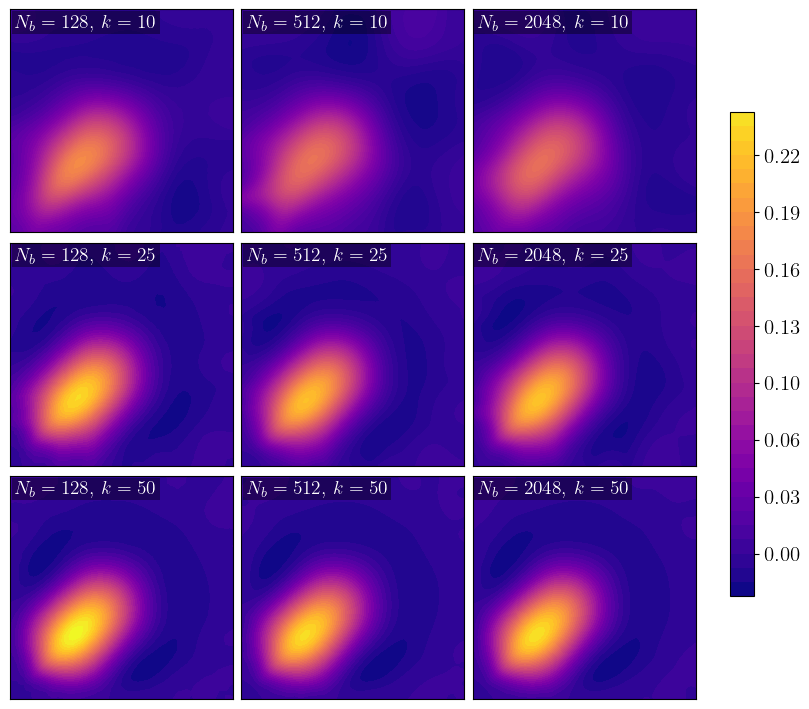

In [ ]:
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def plot_multiple_f(f_list, names=None):
    fig, axes = plt.subplots(3, 3, figsize=(8, 7), constrained_layout=True)
    axes = axes.flatten()

    vmin = min(f.vector().min() for f in f_list)
    vmax = max(f.vector().max() for f in f_list)
    norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

    if names is None:
        names = ['' for _ in axes]

    for ax, func, name in zip(axes, f_list, names):
        plt.sca(ax)
        p = plot(func, title='', cmap='plasma', norm=norm)
        ax.set_xticks([])
        ax.set_yticks([])

        ax.text(
            0.02, 0.98, name,
            transform=ax.transAxes,
            ha="left", va="top",
            fontsize=14,
            color="white",
            bbox=dict(facecolor="black", alpha=0.4, pad=2, edgecolor="none")
        )

    fig.colorbar(p, ax=axes, format="%.2f", shrink=0.7, norm=norm)

    figname = 'solutions_different_Nb_and_k.png'
    plt.savefig(f'../figures/{figname}', dpi=300, bbox_inches='tight')
    plt.show()


N_b_list = [128, 512, 2048] * 3
k_list = [10, 10, 10, 25, 25, 25, 50, 50, 50]
names = [f'$N_b={N_b}$, $k={k}$' for N_b, k in zip(N_b_list, k_list)]

f_list = f_list_10 + f_list_25 + f_list_50
plot_multiple_f(f_list, names=names)

In [15]:
def run_experiment(n_range, k_range):
    """
    Run a single experiment: time the assembly of K and the rSVD approximation
    over a range of mesh shapes (n_range) and a range of target ranks (k_range).
    """
    nn, nk = len(n_range), len(k_range)
    results = {
        'exact': np.zeros(nn),
        'rsvd': np.zeros((nn, nk)),
        'N': [],
        'N_b': []
    }

    for i, n in enumerate(n_range):
        V_h = setup_function_space(n)
        exact = AssembleForwardOperator(V_h=V_h)

        # Time to assemble the exact K
        exact.assemble_K()
        dt_exact = exact.dt

        # Time to approximate K
        rsvd = MatrixFreeRSVD(V_h)
        dt_rsvd = np.zeros(len(k_range))
        for j, k in enumerate(k_range):
            t0 = time()
            U, S, VT = rsvd.mf_rsvd(k=k)
            K = U @ np.diag(S) @ VT
            dt_rsvd[j] = time() - t0

        results['exact'][i] = dt_exact
        results['rsvd'][i, :] = dt_rsvd
        results['N'].append(rsvd.N)
        results['N_b'].append(rsvd.N_b)

    return results


def run_r_experiments(n_range, k_range, r):
    nn, nk = len(n_range), len(k_range)
    results = {
        'exact': np.zeros((r, nn)),  # (repeats, n_range)
        'rsvd': np.zeros((r, nn, nk)),  # (repeats, n_range, k_range)
        'N': [],
        'N_b': []
    }

    progress_bar(0, r)
    for ri in range(r):
        results_i = run_experiment(n_range, k_range)
        results['exact'][ri, :] = results_i['exact']
        results['rsvd'][ri, :, :] = results_i['rsvd']
        progress_bar(ri + 1, r)
    
    results['N'] = results_i['N']
    results['N_b'] = results_i['N_b']

    return results


k_range = np.array([5, 15, 30])
n_range = np.arange(16, 64, 2)
results = run_r_experiments(n_range, k_range, r=2)

[##############################] 2/2


In [16]:
medians = {
    key: np.median(val, axis=0) for key, val in results.items()
}
medians['rsvd'].shape, medians['exact'].shape

((24, 3), (24,))

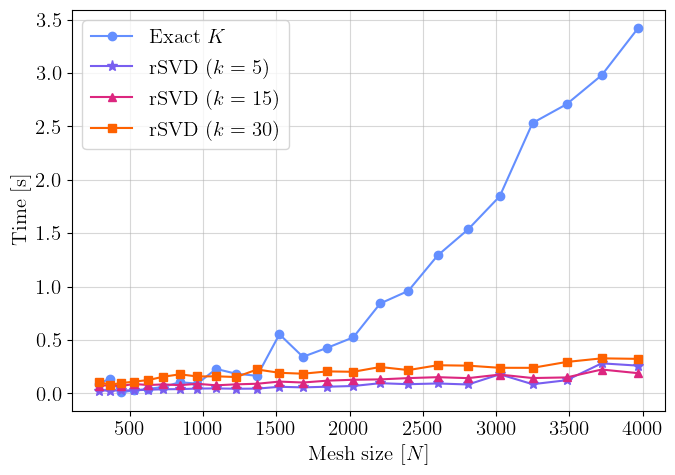

In [18]:
def figure_exact_vs_rsvd_comp_time(medians, k_range):
    fig, axes = plt.subplots(1, 1, figsize=(7, 5))
    ax1 = axes
    k1, k2, k3 = k_range

    x_axis = results['N']
    ax1.plot(x_axis, medians['exact'],      c=C5[0], marker=M[0], ms=MS[0], label='Exact $K$')
    ax1.plot(x_axis, medians['rsvd'][:, 0], c=C5[1], marker=M[1], ms=MS[1], label=f'rSVD ($k={k1}$)')
    ax1.plot(x_axis, medians['rsvd'][:, 1], c=C5[2], marker=M[2], ms=MS[2], label=f'rSVD ($k={k2}$)')
    ax1.plot(x_axis, medians['rsvd'][:, 2], c=C5[3], marker=M[3], ms=MS[3], label=f'rSVD ($k={k3}$)')

    ax1.set_xlabel("Mesh size [$N$]")
    ax1.set_ylabel("Time [s]")
    #ax1.axhline(0, c='black', ls='--', alpha=.5)
    ax1.legend()
    ax1.grid(True, alpha=.5)

    plt.tight_layout()
    plt.plot()

    figname = 'exact_vs_rsvd_comp_time.png'
    plt.savefig(f'../figures/{figname}', dpi=300, bbox_inches='tight')


figure_exact_vs_rsvd_comp_time(medians, k_range)